In [1]:
from package_novqs import *

E0918 03:42:58.745408 1703407 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )
E0918 03:42:58.757555 1703303 cuda_executor.cc:1743] Could not get kernel mode driver version: ( INVALID_ARGUMENT: Version does not match the format X.Y.Z )


JAX device: [CudaDevice(id=0)]


# Model

In [73]:
n_atoms = 4  # N_q = 10
n_orbits = n_atoms
n_electrons = n_atoms

model_name = f"H{n_atoms}Chain"
distance = 2.0

geometry = [
    ("H", (0.0, 0.0, i * distance))
    for i in range(n_atoms)
]

multiplicity = 1 if n_atoms % 2 == 0 else 2

molecule = MolecularData(
    geometry=geometry,
    basis="sto-3g",
    multiplicity=multiplicity,
    charge=0,
    data_directory=os.path.join(os.getcwd(), "data"),
)

molecule = run_pyscf(molecule)

second_q_hamiltonian = molecule.get_molecular_hamiltonian()
jw_hamiltonian = jordan_wigner(second_q_hamiltonian)
Ham = qml.import_operator(jw_hamiltonian)

H_mat = qml.matrix(Ham)
eigvals, eigvecs = jnp.linalg.eigh(H_mat)
Eg = eigvals[0]

# Ansatz

In [74]:
# 1. Instantiate the ansatz object
Nq = n_orbits * 2
n_blocks = 3   # Adjust manually
n_layers = Nq // 2
ansatz = fSimAnsatz(Nq, n_blocks, n_layers)

# 2. Create the device and circuit
dev = qml.device("default.qubit", wires=Nq)
hf_state = qml.qchem.hf_state(n_electrons, Nq)
init_state = 'US' # uniform superposition state (US), Hartree Fock state (HF)
init_dist = 'Zeros'  # Gaussian, Uniform, Zeros, Perturbation
circuit = get_circuit(dev, ansatz, init_state, hf_state)
circuits_fn = jax.jit(jax.vmap(circuit, in_axes=(0,)))   # for multi ansatze

# 3. Initialize the parameters and run
print("--- Quantum circuit diagram ---")
params = init_params(Nq, n_blocks, n_layers, Ns=1, method=init_dist, seed=0)
print(qml.draw(circuit)(params))

--- Quantum circuit diagram ---
 0: ──H─╭IsingXY(0.00)─╭●────────╭SWAP────────────────────────────────╭IsingXY(0.00)─╭●─────── ···
 1: ──H─╰IsingXY(0.00)─╰Rϕ(0.00)─╰SWAP─╭IsingXY(0.00)─╭●────────╭SWAP─╰IsingXY(0.00)─╰Rϕ(0.00) ···
 2: ──H─╭IsingXY(0.00)─╭●────────╭SWAP─╰IsingXY(0.00)─╰Rϕ(0.00)─╰SWAP─╭IsingXY(0.00)─╭●─────── ···
 3: ──H─╰IsingXY(0.00)─╰Rϕ(0.00)─╰SWAP─╭IsingXY(0.00)─╭●────────╭SWAP─╰IsingXY(0.00)─╰Rϕ(0.00) ···
 4: ──H─╭IsingXY(0.00)─╭●────────╭SWAP─╰IsingXY(0.00)─╰Rϕ(0.00)─╰SWAP─╭IsingXY(0.00)─╭●─────── ···
 5: ──H─╰IsingXY(0.00)─╰Rϕ(0.00)─╰SWAP─╭IsingXY(0.00)─╭●────────╭SWAP─╰IsingXY(0.00)─╰Rϕ(0.00) ···
 6: ──H─╭IsingXY(0.00)─╭●────────╭SWAP─╰IsingXY(0.00)─╰Rϕ(0.00)─╰SWAP─╭IsingXY(0.00)─╭●─────── ···
 7: ──H─╰IsingXY(0.00)─╰Rϕ(0.00)─╰SWAP─╭IsingXY(0.00)─╭●────────╭SWAP─╰IsingXY(0.00)─╰Rϕ(0.00) ···
 8: ──H─╭IsingXY(0.00)─╭●────────╭SWAP─╰IsingXY(0.00)─╰Rϕ(0.00)─╰SWAP─╭IsingXY(0.00)─╭●─────── ···
 9: ──H─╰IsingXY(0.00)─╰Rϕ(0.00)─╰SWAP─╭IsingXY(0.00)─╭●────────╭SWAP─╰IsingX

# NOVQS

In [75]:
# Parameters
Ns = 5
params = init_params(Nq, n_blocks, n_layers, Ns, method=init_dist, seed=0)

coeffs_a = jnp.ones((Ns,))  # ones  zeros
coeffs_a = coeffs_a.at[0].set(1.0)
coeffs_b = jnp.zeros((Ns,)) 
coeffs_init = coeffs_a * jnp.exp(1j * coeffs_b)
params_coeffs = jnp.concatenate([params, coeffs_a, coeffs_b])  # (n_params + Ns * 2,)

# 1. Instantiate
evolver = MultiStateEvolver(circuit, eigvals, eigvecs, Nq, Ns, reg=1e-8)


states = circuits_fn(params.reshape(Ns, -1))  # (Ns, dim)
psi0 = coeffs_init @ states         # (dim,)
norm = jnp.linalg.norm(psi0)
psi0 = psi0 / norm
eig_coeffs = eigvecs.conj().T @ psi0
print(jnp.abs(eig_coeffs)**2)

[1.79522107e-07 2.87296863e-06 5.91713702e-06 ... 8.35607983e-05
 2.44140625e-04 2.44140625e-04]


In [76]:
# Simulation parameters
T = 5.0
dt = 0.005
steps = int(T / dt)

time_points = jnp.zeros(steps + 1)
trajectory = jnp.zeros((len(params_coeffs), steps + 1))  

time_points = time_points.at[0].set(0.0)
trajectory = trajectory.at[:, 0].set(params_coeffs)

# Time-stepping loop
for i in tqdm(range(steps), desc="Real Time Evolution"):

    t = i * dt
    params_coeffs = rk4_step(evolver.theta_dot_rte, t, params_coeffs, dt) 

    time_points = time_points.at[i + 1].set(t + dt)           # Time points
    trajectory = trajectory.at[:, i + 1].set(params_coeffs)   # Parameter trajectory shape=(n_params_coeffs, n_time_points)

Real Time Evolution:   1%|          | 6/1000 [03:08<8:40:06, 31.39s/it] 


KeyboardInterrupt: 

## Occupation

In [ ]:
# 1. Set up the exact solver
rte_solver = exactRTE(eigvals, eigvecs, eig_coeffs)

# 2. Instantiate the fidelity calculator (assuming Ns=2)
occ_calc = MultiStateOccupationCalculator(circuit, rte_solver, Ns, Nq)

# 3. Batched calculation
# Assume trajectory has shape (Total_params, steps)
# Pass the transposed array so each row represents one time step
params_all = trajectory.T
occupations_novqs, occupations_exact = occ_calc.compute_batched(params_all, time_points, batch_size=100)

Computing occupations: 100%|██████████| 41/41 [00:21<00:00,  1.92it/s]


## Save data

In [ ]:
if not os.path.exists("data"):
    os.makedirs("data")

file_path = f"data/NOVQS-RTE-occupations-{model_name}-dist={distance}-Nq={Nq}-T={T}-dt={dt}-L={n_layers}-B={n_blocks}-Ns={Ns}-{init_state}-{init_dist}.npy"

data_to_save = {
    "occupations_novqs": occupations_novqs,
    "occupations_exact": occupations_exact,
    "time_points": time_points  
}
jnp.save(file_path, data_to_save)

# Plot

## spatial-orbit occupation

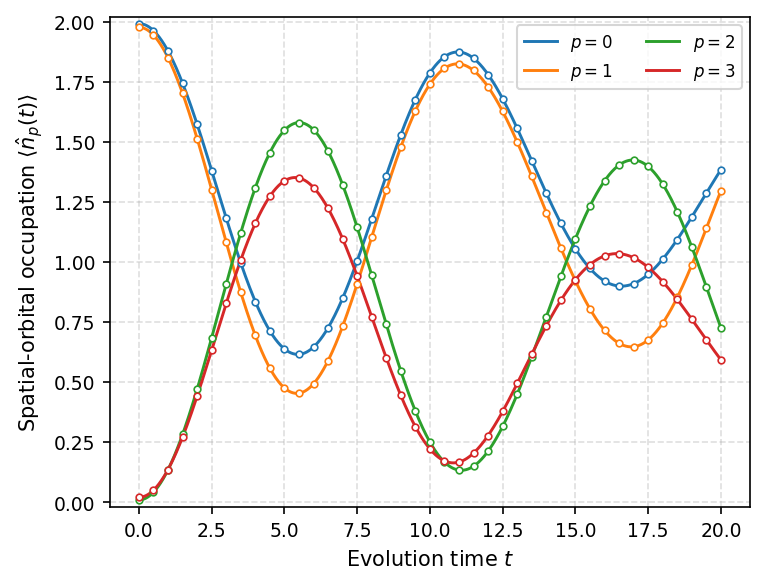

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

#init_state = 'HF'
#init_dist = 'Perturbation'

#init_state = 'US'
#init_dist = 'Zeros'
# Construct the data file path
file_path = (f"data/NOVQS-RTE-occupations-H4Chain-dist=2.0-Nq=8-T=20.0-dt=0.005-L=4-B=3-Ns=3-HF-Perturbation.npy")
#file_path = (f"data/NOVQS-RTE-occupations-H4Chain-dist=2.0-Nq=8-T=20.0-dt=0.005-L=4-B=3-Ns=3-US-Zeros.npy")

data = np.load(file_path, allow_pickle=True).item()
occupations_novqs = np.asarray(data["occupations_novqs"])
occupations_exact = np.asarray(data["occupations_exact"])
time_points = np.asarray(data["time_points"])

# Number of spatial orbitals
Nq = 8
n_spatial_orbitals = Nq // 2

# n_i = n_{iα} + n_{iβ}
spatial_occupations_novqs = (
    occupations_novqs[:, 0::2] + occupations_novqs[:, 1::2]
)
spatial_occupations_exact = (
    occupations_exact[:, 0::2] + occupations_exact[:, 1::2]
)



# Start plotting
fig, ax = plt.subplots(figsize=(5.2, 4.0), dpi=150)

tab10_colors = plt.colormaps["tab10"].colors
colors = [tab10_colors[p % len(tab10_colors)] for p in range(n_spatial_orbitals)]
mark_interval = 100

# NOVQS: solid lines, drawn at a lower z-order
for p in range(n_spatial_orbitals):
    ax.plot(
        time_points,
        spatial_occupations_novqs[:, p],
        linestyle="-",
        color=colors[p],
        linewidth=1.4,
        label=fr"$p={p}$",
        zorder=2,
    )

# Exact: dashed lines and open circles in matching colors, drawn at a higher z-order
for p in range(n_spatial_orbitals):
    ax.plot(
        time_points,
        spatial_occupations_exact[:, p],
        linestyle="",
        color=colors[p],
        linewidth=1.1,
        marker="o",
        markersize=3.2,
        markerfacecolor="white",
        markeredgecolor=colors[p],
        markeredgewidth=0.8,
        markevery=mark_interval,
        zorder=3,
    )

ax.set_xlabel(r"Evolution time $t$", fontsize=10)
ax.set_ylabel(
    r"Spatial-orbital occupation $\langle\hat{n}_p(t)\rangle$",
    fontsize=10,
)

ax.set_ylim(-0.02, 2.02)
#ax.set_ylim(0.9, 1.1)
ax.tick_params(axis="both", which="major", labelsize=9)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()

#plt.savefig(
#    f"fig/{model_name}-RTE-occupations-{init_state}.pdf",
#    bbox_inches="tight",
#)

plt.show()